/var/folders/kr/c215w16n7756009kd5l3llzm0000gn/T/ipykernel_29713/4008369932.py:133: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Times New Roman.
  plt.tight_layout()
/var/folders/kr/c215w16n7756009kd5l3llzm0000gn/T/ipykernel_29713/4008369932.py:136: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Times New Roman.
  plt.savefig('Figure_4_3_LearningCurves.pdf')
/var/folders/kr/c215w16n7756009kd5l3llzm0000gn/T/ipykernel_29713/4008369932.py:136: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Times New Roman.
  plt.savefig('Figure_4_3_LearningCurves.pdf')
/var/folders/kr/c215w16n7756009kd5l3llzm0000gn/T/ipykernel_29713/4008369932.py:138: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Times New Roman.
  plt.savefig('Figure_4_3_LearningCurves.png')


图表已生成：Figure_4_3_LearningCurves.pdf


/opt/anaconda3/envs/pubmed_crawler/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


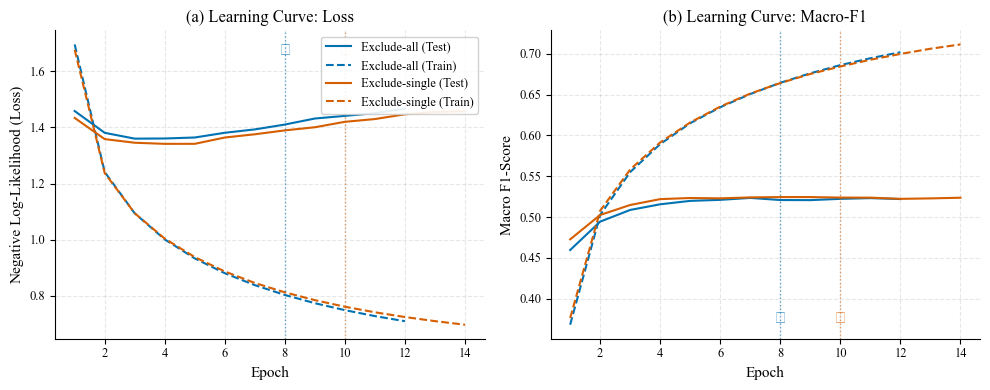

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# ==========================================
# 1. 绘图风格设置 (符合学术论文标准)
# ==========================================
def set_pub_style():
    plt.rcParams.update({
        "font.family": "serif",           # 使用衬线体 (匹配 LaTeX)
        "font.serif": ["Times New Roman", "DejaVu Serif"], 
        "font.size": 10,                  # 字号
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "lines.linewidth": 1.5,
        "axes.grid": True,                # 开启网格
        "grid.alpha": 0.3,                # 网格透明度，避免喧宾夺主
        "grid.linestyle": "--",
        "figure.figsize": (10, 4),        # 宽长比，适合放在页宽
        "savefig.dpi": 300,               # 高DPI
        "savefig.bbox": "tight",          # 去除多余白边
        "axes.spines.top": False,         # 去掉上边框
        "axes.spines.right": False        # 去掉右边框
    })

# ==========================================
# 2. 数据读取函数
# ==========================================
def load_log(filepath):
    """读取单个JSON日志文件"""
    with open(filepath, 'r') as f:
        return json.load(f)

# ==========================================
# 3. 主逻辑
# ==========================================
def generate_thesis_plot():
    set_pub_style()

    # ---- 路径配置 (请根据你的实际文件夹结构修改这里) ----
    # 假设脚本放在截图所示的根目录下
    path_exclude_all = "/Users/jannik/KAN-Brain-Single-Voxel-Segmentaion/论文复现/论文图片/exclude数据/exclude all.json"
    
    # 我们选择 'exclude 5.json' 作为 Exclude-single 的代表 (Run 5)
    # 你也可以改为 loop 读取所有计算均值，但论文中说的是 "one representative run"
    path_exclude_single = "/Users/jannik/KAN-Brain-Single-Voxel-Segmentaion/论文复现/论文图片/exclude数据/exclude 5.json" 

    # ---- 加载数据 ----
    try:
        data_all = load_log(path_exclude_all)
        data_single = load_log(path_exclude_single)
    except FileNotFoundError as e:
        print(f"Error: 找不到文件。请检查路径配置。\n详情: {e}")
        # 为了演示，这里生成伪数据防止代码报错（实际运行时请删除这部分）
        return

    # 提取 Exclude-all 数据
    epochs_all = range(1, len(data_all['train_loss']) + 1)
    loss_train_all = data_all['train_loss']
    loss_test_all = data_all['test_loss']
    f1_train_all = data_all['train_f1']
    f1_test_all = data_all['test_f1']
    # 注意：JSON中的 best_epoch 通常是 0-indexed，绘图时对应 x 轴需要 +1
    best_epoch_all = data_all['best_epoch'] + 1 

    # 提取 Exclude-single 数据
    epochs_single = range(1, len(data_single['train_loss']) + 1)
    loss_train_single = data_single['train_loss']
    loss_test_single = data_single['test_loss']
    f1_train_single = data_single['train_f1']
    f1_test_single = data_single['test_f1']
    best_epoch_single = data_single['best_epoch'] + 1

    # ---- 开始绘图 (双子图) ----
    fig, (ax1, ax2) = plt.subplots(1, 2)

    # 颜色定义 (Colorblind-friendly safe colors)
    # 蓝色系代表 Exclude-all
    c_all_test = '#0072B2'  # 深蓝
    c_all_train = '#56B4E9' # 浅蓝
    
    # 橙色系代表 Exclude-single
    c_single_test = '#D55E00' # 深橙/朱红
    c_single_train = '#E69F00' # 浅橙

    # --- Subplot 1: Loss (NLL) ---
    # 绘制 Exclude-all
    ax1.plot(epochs_all, loss_test_all, label='Exclude-all (Test)', color=c_all_test, linestyle='-')
    ax1.plot(epochs_all, loss_train_all, label='Exclude-all (Train)', color=c_all_test, linestyle='--')
    # 绘制 Exclude-single
    ax1.plot(epochs_single, loss_test_single, label='Exclude-single (Test)', color=c_single_test, linestyle='-')
    ax1.plot(epochs_single, loss_train_single, label='Exclude-single (Train)', color=c_single_test, linestyle='--')
    
    # 标注 Best Epoch (竖线)
    ax1.axvline(best_epoch_all, color=c_all_test, linestyle=':', alpha=0.6, linewidth=1)
    ax1.axvline(best_epoch_single, color=c_single_test, linestyle=':', alpha=0.6, linewidth=1)
    # 添加 Best Epoch 文字标注 (可选，保持简洁可去掉)
    ax1.text(best_epoch_all, ax1.get_ylim()[1]*0.95, '★', color=c_all_test, ha='center', fontsize=12)
    ax1.text(best_epoch_single, ax1.get_ylim()[1]*0.95, '★', color=c_single_test, ha='center', fontsize=12)

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Negative Log-Likelihood (Loss)')
    ax1.set_title('(a) Learning Curve: Loss')
    # 优化 Legend：只显示 Test 线，或者全显示。为了论文严谨，建议全显示但放合适位置
    ax1.legend(loc='upper right', frameon=True, framealpha=0.9)

    # --- Subplot 2: Macro-F1 ---
    # 绘制 Exclude-all
    ax2.plot(epochs_all, f1_test_all, label='Exclude-all (Test)', color=c_all_test, linestyle='-')
    ax2.plot(epochs_all, f1_train_all, label='Exclude-all (Train)', color=c_all_test, linestyle='--')
    # 绘制 Exclude-single
    ax2.plot(epochs_single, f1_test_single, label='Exclude-single (Test)', color=c_single_test, linestyle='-')
    ax2.plot(epochs_single, f1_train_single, label='Exclude-single (Train)', color=c_single_test, linestyle='--')

    # 标注 Best Epoch
    ax2.axvline(best_epoch_all, color=c_all_test, linestyle=':', alpha=0.6, linewidth=1)
    ax2.axvline(best_epoch_single, color=c_single_test, linestyle=':', alpha=0.6, linewidth=1)
    ax2.text(best_epoch_all, ax2.get_ylim()[0] + (ax2.get_ylim()[1]-ax2.get_ylim()[0])*0.05, '★', color=c_all_test, ha='center', fontsize=12)
    ax2.text(best_epoch_single, ax2.get_ylim()[0] + (ax2.get_ylim()[1]-ax2.get_ylim()[0])*0.05, '★', color=c_single_test, ha='center', fontsize=12)

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1-Score')
    ax2.set_title('(b) Learning Curve: Macro-F1')
    # 为了避免图例遮挡曲线，不重复显示图例，或者放在右下角
    # ax2.legend(loc='lower right') 

    # ---- 布局调整与保存 ----
    plt.tight_layout()
    
    # 保存为 PDF (矢量图，推荐插入 LaTeX)
    plt.savefig('Figure_4_3_LearningCurves.pdf')
    # 保存为 PNG (备用)
    plt.savefig('Figure_4_3_LearningCurves.png')
    
    print("图表已生成：Figure_4_3_LearningCurves.pdf")

if __name__ == "__main__":
    generate_thesis_plot()